<a href="https://colab.research.google.com/github/qkrehdwo1144/Emergency_Patient_Priority_System/blob/main/Hybrid_Sort.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

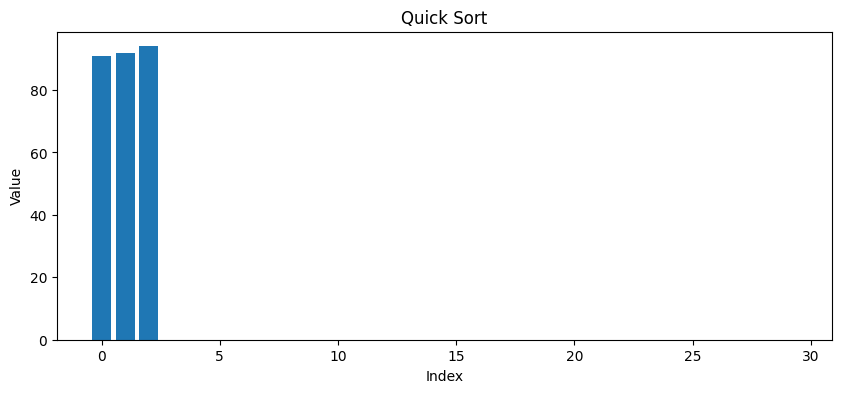

⚠ 분할 불균형 감지
→ Merge Sort로 전환

정렬 완료
사용 알고리즘: Quick Sort → Merge Sort
실행 시간: 1.587574초
비교 횟수: 95회

정렬 결과:
[4, 10, 13, 17, 20, 24, 28, 29, 31, 33, 34, 37, 56, 62, 64, 66, 70, 71, 74, 75, 80, 84, 85, 86, 91, 92, 94, 98, 99, 99]


In [4]:
import random
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output


random_data = [random.randint(1, 100) for _ in range(30)]

almost_sorted_data = list(range(1, 31))
almost_sorted_data[10], almost_sorted_data[11] = almost_sorted_data[11], almost_sorted_data[10]

reverse_data = list(range(30, 0, -1))


def draw_data(data, title="Sorting..."):
    clear_output(wait=True)

    plt.figure(figsize=(10,4))
    plt.bar(range(len(data)), data)

    plt.title(title)
    plt.xlabel("Index")
    plt.ylabel("Value")

    plt.show()

    time.sleep(0.05)



def insertion_sort(arr, visualize=True):

    comparisons = 0

    start = time.time()

    for i in range(1, len(arr)):

        key = arr[i]
        j = i - 1

        while j >= 0 and arr[j] > key:

            comparisons += 1

            arr[j+1] = arr[j]
            j -= 1

            if visualize:
                draw_data(arr, "Insertion Sort")

        if j >= 0:
            comparisons += 1

        arr[j+1] = key

    end = time.time()

    return {
        'algorithm': 'Insertion Sort',
        'time': end - start,
        'comparisons': comparisons,
        'sorted_array': arr
    }



def merge_sort(arr, visualize=True):

    comparisons = [0]

    start = time.time()

    def merge(left, right):

        result = []
        i = j = 0

        while i < len(left) and j < len(right):

            comparisons[0] += 1

            if left[i] < right[j]:
                result.append(left[i])
                i += 1

            else:
                result.append(right[j])
                j += 1

        result.extend(left[i:])
        result.extend(right[j:])

        return result

    def divide(array):

        if len(array) <= 1:
            return array

        mid = len(array) // 2

        left = divide(array[:mid])
        right = divide(array[mid:])

        merged = merge(left, right)

        if visualize:
            draw_data(
                merged + [0]*(len(arr)-len(merged)),
                "Merge Sort"
            )

        return merged

    sorted_arr = divide(arr)

    end = time.time()

    return {
        'algorithm': 'Merge Sort',
        'time': end - start,
        'comparisons': comparisons[0],
        'sorted_array': sorted_arr
    }



def quick_sort(arr, visualize=True):

    comparisons = [0]
    switched_to_merge = [False]

    start = time.time()

    def sort(array):

        if len(array) <= 1:
            return array

        pivot = array[len(array)//2]

        left = []
        middle = []
        right = []

        for x in array:

            comparisons[0] += 1

            if x < pivot:
                left.append(x)

            elif x > pivot:
                right.append(x)

            else:
                middle.append(x)


        if len(left) < len(array)*0.1 or len(right) < len(array)*0.1:

            switched_to_merge[0] = True

            print("⚠ 분할 불균형 감지")
            print("→ Merge Sort로 전환")

            merge_result = merge_sort(array, visualize=False)

            return merge_result['sorted_array']

        combined = left + middle + right

        if visualize:
            draw_data(
                combined + [0]*(len(arr)-len(combined)),
                "Quick Sort"
            )

        return sort(left) + middle + sort(right)

    sorted_arr = sort(arr)

    end = time.time()

    algorithm_name = "Quick Sort"

    if switched_to_merge[0]:
        algorithm_name = "Quick Sort → Merge Sort"

    return {
        'algorithm': algorithm_name,
        'time': end - start,
        'comparisons': comparisons[0],
        'sorted_array': sorted_arr
    }



def is_almost_sorted(arr):

    count = 0

    for i in range(len(arr)-1):

        if arr[i] <= arr[i+1]:
            count += 1

    ratio = count / (len(arr)-1)

    return ratio >= 0.9



def hybrid_sort(arr):

    print("============================")
    print("하이브리드 정렬 분석 시작")
    print("============================")


    if len(arr) <= 16:

        print("선택된 알고리즘: Insertion Sort")
        print("이유: 데이터 수가 적음")

        return insertion_sort(arr)


    elif is_almost_sorted(arr):

        print("선택된 알고리즘: Insertion Sort")
        print("이유: 거의 정렬된 상태")

        return insertion_sort(arr)


    else:

        print("선택된 알고리즘: Quick Sort")
        print("이유: 평균 속도가 빠름")

        return quick_sort(arr)


print("\n===== 데이터 선택 =====")
print("1. 랜덤 데이터")
print("2. 거의 정렬된 데이터")
print("3. 역정렬 데이터")

choice = input("번호 입력: ")

if choice == '1':
    data = random_data.copy()

elif choice == '2':
    data = almost_sorted_data.copy()

elif choice == '3':
    data = reverse_data.copy()

else:
    print("잘못된 입력 → 랜덤 데이터 사용")
    data = random_data.copy()

print("\n정렬 전 데이터:")
print(data)

result = hybrid_sort(data)

print("\n============================")
print("정렬 완료")
print("============================")

print(f"사용 알고리즘: {result['algorithm']}")
print(f"실행 시간: {result['time']:.6f}초")
print(f"비교 횟수: {result['comparisons']}회")

print("\n정렬 결과:")
print(result['sorted_array'])